<a href="https://colab.research.google.com/github/OrianEdd/klasifikasi_svm/blob/main/Klasifikasi%20data%20SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from sklearn.datasets import load_iris
import pandas as pd

# Memuat dataset contoh
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(f"Ukuran Dataset: {df.shape}")
df.head()

Ukuran Dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(df.drop(columns=['target']))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
y = df['target'].values

In [19]:
from sklearn.model_selection import train_test_split

# Membagi menjadi 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data Train: {X_train.shape}, Data Test: {X_test.shape}")

Data Train: (120, 4), Data Test: (30, 4)


In [20]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
model_svm.fit(X_train, y_train)

SVC()

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = model_svm.predict(X_test)
y_pred_train = model_svm.predict(X_train)

print("--- METRIK EVALUASI (DATA TEST) ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='macro'):.2f}")

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Train: {acc_train:.2f} vs Akurasi Test: {acc_test:.2f}")

--- METRIK EVALUASI (DATA TEST) ---
Accuracy  : 0.97
Precision : 0.97
Recall    : 0.97
F1-Score  : 0.97

Akurasi Train: 0.97 vs Akurasi Test: 0.97


/tmp/ipykernel_4745/604741115.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


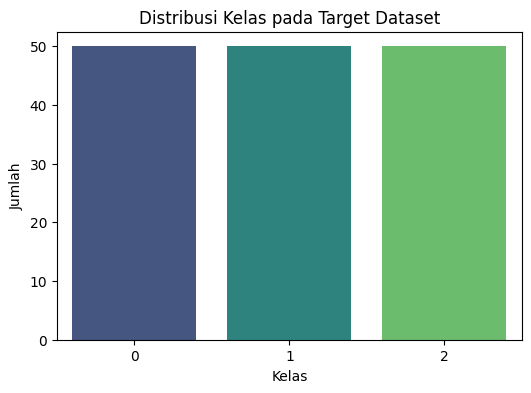

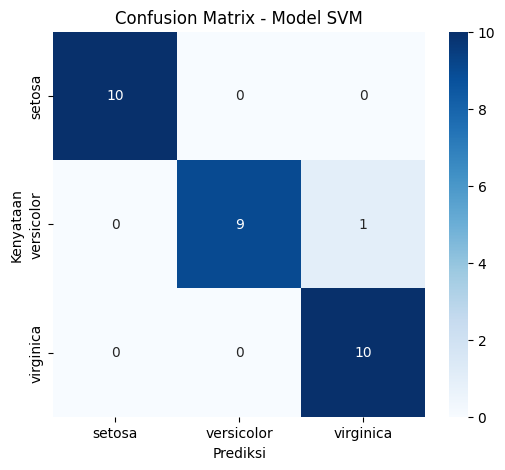

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribusi Kelas pada Target Dataset')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Model SVM')
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.show()